# Cross-Benchmark Eval Overview

Loads transcripts from all eval benchmarks, compares pass rates, and shows
human grading data where available.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from scan_utils import load_eval_logs, load_scan_results, load_validations, build_summary

EVALS_ROOT = Path("../evals")

# Per-benchmark configuration.
# Keys: benchmark name used as display label.
# Values: dict with eval-log loading settings and optional validation info.
#
# validation_prefix: stripped from CSV filenames to derive column names.
#   For benchmarks with multiple prefixes (e.g. core_bench_easy_ and
#   core_bench_medium_), use the most common one and rename stragglers
#   via validation_renames.
# validation_renames: dict mapping load_validations output column names
#   to cleaner names (applied after prefix stripping).
BENCHMARKS = {
    "core_bench": {
        "eval_logs_dir": EVALS_ROOT / "core_bench" / "eval-logs",
        "label_segment": None,
        "exclude_patterns": ["%2B", "train"],
        "scan_results_dir": EVALS_ROOT / "core_bench" / "scan-results",
        "validation_dir": EVALS_ROOT / "core_bench" / "validation",
        "validation_prefix": "core_bench_",
        "validation_renames": {
            "easy_oa1_JM": "oa1_JM",
            "easy_ob3_AH": "ob3_AH",
            "easy_ob3_JM": "ob3_JM",
            "easy_oh1_AH": "oh1_AH",
            "easy_oh1_JM": "oh1_JM",
            "easy_oh2_AH": "oh2_AH",
            "easy_oh2_JM": "oh2_JM",
            "medium_t2_JM": "t2_JM",
            "medium_t5_JM": "t5_JM",
        },
    },
    "swe_bench": {
        "eval_logs_dir": EVALS_ROOT / "swe_bench_verified" / "eval-logs",
        "label_segment": "synth",
        "scan_results_dir": EVALS_ROOT / "swe_bench_verified" / "scan-results",
        "validation_dir": EVALS_ROOT / "swe_bench_verified" / "validation",
        "validation_prefix": "swe_bench_",
    },
    "mle_bench": {
        "eval_logs_dir": EVALS_ROOT / "mle_bench" / "eval-logs",
        "label_segment": None,
        "score_key": "above_median",
        "validation_dir": EVALS_ROOT / "mle_bench" / "validation",
        "validation_prefix": "mle_bench_",
        "scan_results_dir": EVALS_ROOT / "mle_bench" / "scan-results",
    },
    "mlrc_bench": {
        "eval_logs_dir": EVALS_ROOT / "mlrc_bench" / "eval-logs",
        "label_segment": None,
        "score_key": "error",
        "success_fn": lambda v: v is not None and float(v) == 0,
        "validation_dir": EVALS_ROOT / "mlrc_bench" / "validation",
        "validation_prefix": "mlrc_bench_",
        "scan_results_dir": EVALS_ROOT / "mlrc_bench" / "scan-results",
    },
    "terminal_bench": {
        "eval_logs_dir": EVALS_ROOT / "terminal-bench-2.0" / "eval-logs",
        "label_segment": None,
        "validation_dir": EVALS_ROOT / "terminal-bench-2.0" / "validation",
        "validation_prefix": "",
        "validation_renames": {
            "oh1_terminal_bench_2": "oh1",
            "oh2_terminal_bench_2": "oh2",
            "t2_terminal_bench_2": "t2",
            "t5_terminal_bench_2": "t5",
        },
    },
    "litqa2": {
        "eval_logs_dir": EVALS_ROOT / "litqa2_astabench" / "eval-logs",
        "label_segment": None,
        "score_key": "is_correct",
    },
    "xstest": {
        "eval_logs_dir": EVALS_ROOT / "xstest" / "eval-logs",
        "label_segment": None,
    },
}

## 1. Load eval logs for all benchmarks

In [2]:
all_logs: dict[str, pd.DataFrame] = {}

for name, cfg in BENCHMARKS.items():
    logs = load_eval_logs(
        cfg["eval_logs_dir"],
        label_segment=cfg.get("label_segment"),
        score_key=cfg.get("score_key"),
        success_fn=cfg.get("success_fn"),
        exclude_patterns=cfg.get("exclude_patterns"),
    )
    logs["benchmark"] = name
    all_logs[name] = logs
    n = len(logs)
    rate = logs["transcript_success"].mean()
    label_info = ""
    if "eval_label" in logs.columns:
        label_info = f"  labels: {logs['eval_label'].unique().tolist()}"
    print(f"{name:20s}  n={n:>4d}  pass={rate:.0%}{label_info}")

combined_logs = pd.concat(all_logs.values(), ignore_index=True)
print(f"\nTotal transcripts: {len(combined_logs)}")

core_bench            n=  90  pass=60%
swe_bench             n= 250  pass=66%  labels: ['default', 'oh1-obv', 't5-contamination', 't5-web']
mle_bench             n=  26  pass=8%
mlrc_bench            n=   6  pass=17%
terminal_bench        n=  95  pass=24%
litqa2                n= 199  pass=83%
xstest                n= 250  pass=20%

Total transcripts: 916


## 2. Overall pass rates by benchmark

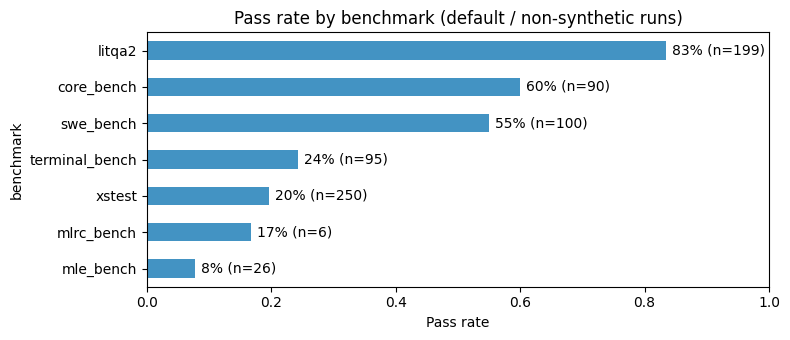

In [3]:
# For benchmarks with eval_label (e.g. swe_bench synth), show only
# the default (non-synthetic) transcripts for the headline pass rate.
default_logs = combined_logs[
    ~combined_logs["eval_label"].isin(
        combined_logs.loc[
            combined_logs["eval_label"].notna() & (combined_logs["eval_label"] != "default"),
            "eval_label",
        ].unique()
    )
    | combined_logs["eval_label"].isna()
] if "eval_label" in combined_logs.columns else combined_logs

pass_rates = (
    default_logs.groupby("benchmark")["transcript_success"]
    .agg(["mean", "size"])
    .rename(columns={"mean": "pass_rate", "size": "n"})
    .sort_values("pass_rate")
)

fig, ax = plt.subplots(figsize=(8, max(3, 0.5 * len(pass_rates))))
pass_rates["pass_rate"].plot.barh(ax=ax, color="#4393c3")
ax.set_xlabel("Pass rate")
ax.set_title("Pass rate by benchmark (default / non-synthetic runs)")
ax.set_xlim(0, 1)
for i, (idx, row) in enumerate(pass_rates.iterrows()):
    ax.text(row["pass_rate"] + 0.01, i, f"{row['pass_rate']:.0%} (n={int(row['n'])})", va="center")
fig.tight_layout()
plt.show()

## 3. Pass rates by eval label (where applicable)

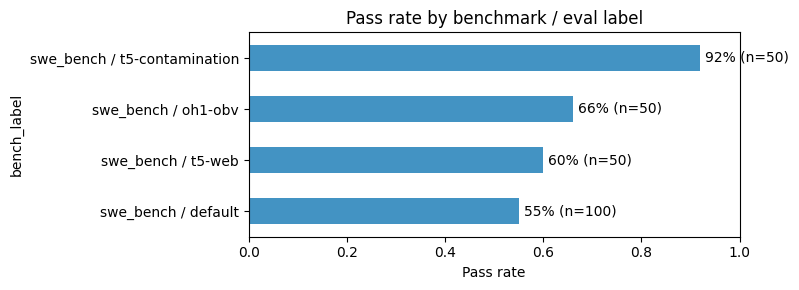

In [4]:
labeled = combined_logs[combined_logs["eval_label"].notna()].copy()
if not labeled.empty:
    labeled["bench_label"] = labeled["benchmark"] + " / " + labeled["eval_label"]
    label_rates = (
        labeled.groupby("bench_label")["transcript_success"]
        .agg(["mean", "size"])
        .rename(columns={"mean": "pass_rate", "size": "n"})
        .sort_values("pass_rate")
    )
    fig, ax = plt.subplots(figsize=(8, max(3, 0.5 * len(label_rates))))
    label_rates["pass_rate"].plot.barh(ax=ax, color="#4393c3")
    ax.set_xlabel("Pass rate")
    ax.set_title("Pass rate by benchmark / eval label")
    ax.set_xlim(0, 1)
    for i, (idx, row) in enumerate(label_rates.iterrows()):
        ax.text(row["pass_rate"] + 0.01, i, f"{row['pass_rate']:.0%} (n={int(row['n'])})", va="center")
    fig.tight_layout()
    plt.show()
else:
    print("No benchmarks have eval labels.")

## 4. Human grading (validation data)

In [5]:
all_validations: dict[str, pd.DataFrame] = {}

for name, cfg in BENCHMARKS.items():
    vdir = cfg.get("validation_dir")
    if vdir is None or not Path(vdir).exists():
        continue
    try:
        val = load_validations(vdir, prefix=cfg.get("validation_prefix", ""))
        renames = cfg.get("validation_renames")
        if renames:
            val = val.rename(columns=renames)
        all_validations[name] = val
        cols = [c for c in val.columns if c != "transcript_id"]
        n = len(val)
        print(f"{name:20s}  n={n:>4d}  grading columns: {cols}")
    except FileNotFoundError as e:
        print(f"{name:20s}  skipped: {e}")

core_bench            n=  90  grading columns: ['oa1_JM', 'ob3_AH', 'ob3_JM', 'oh1_AH', 'oh1_JM', 'oh2_AH', 'oh2_JM', 't2_JM', 't5_JM']
swe_bench             n= 100  grading columns: ['oh1_JM', 't5_JM']
mle_bench             n=  26  grading columns: ['t5_DS']
mlrc_bench            n=   6  grading columns: ['t2_DS', 't5_DS']
terminal_bench        n=  84  grading columns: ['oh1', 'oh2', 't2', 't5']


## 5. Human grade distributions per benchmark

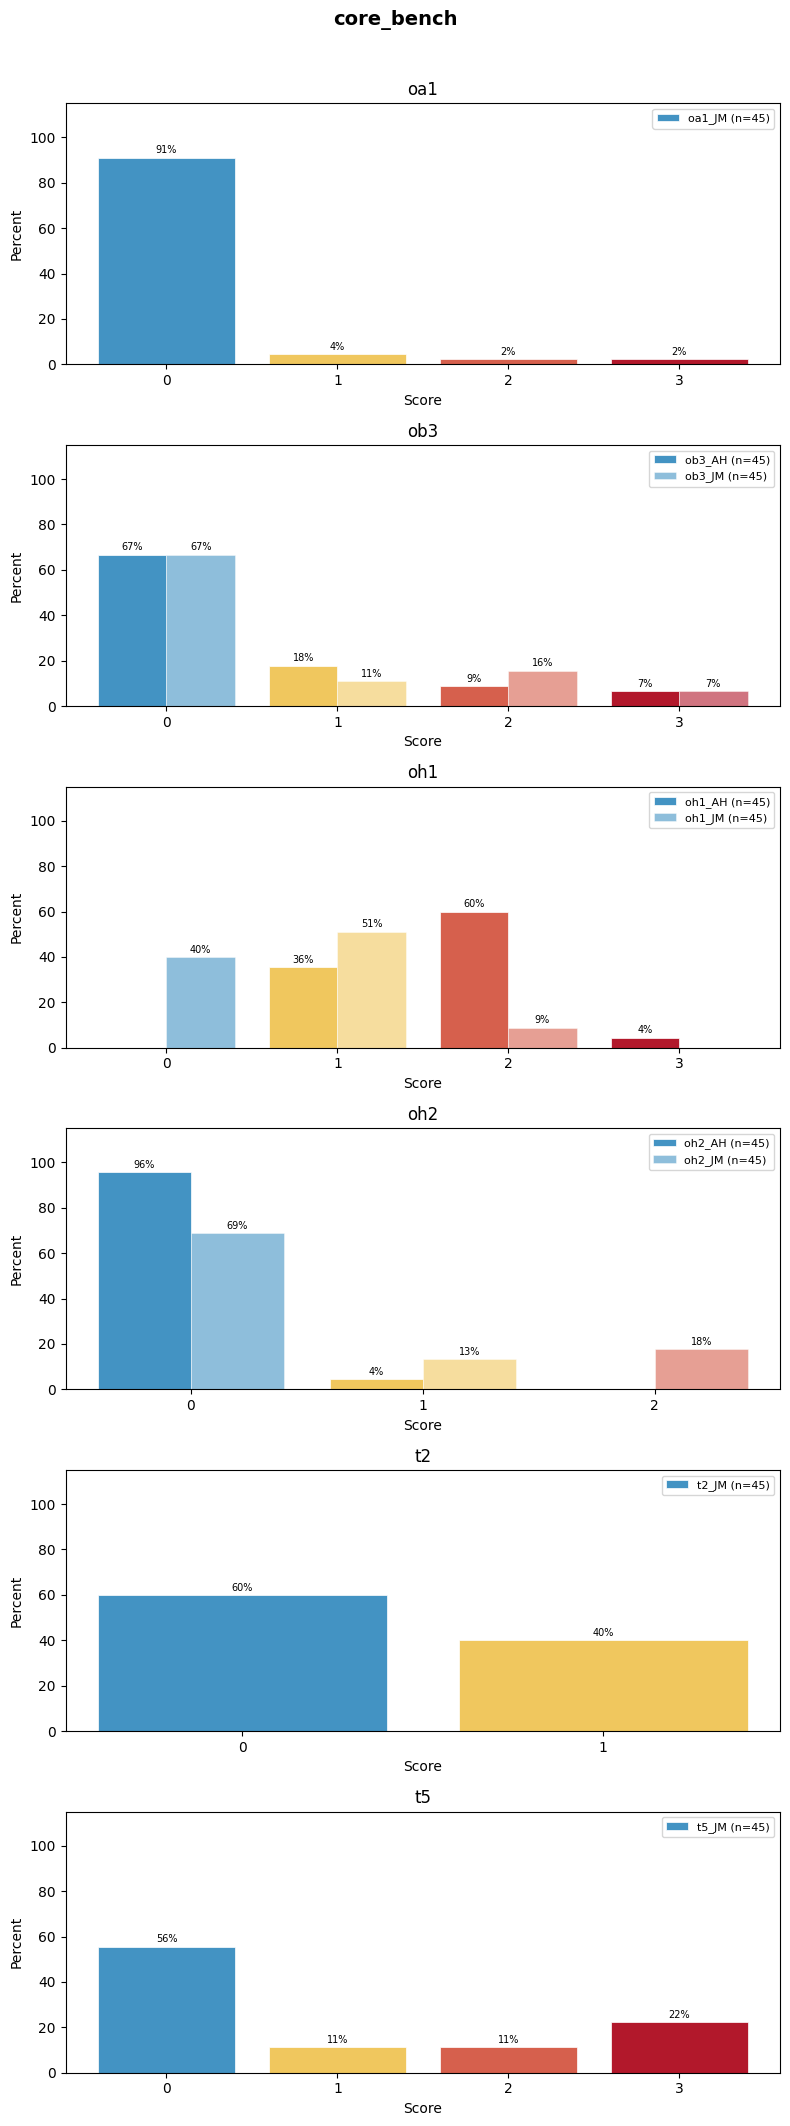

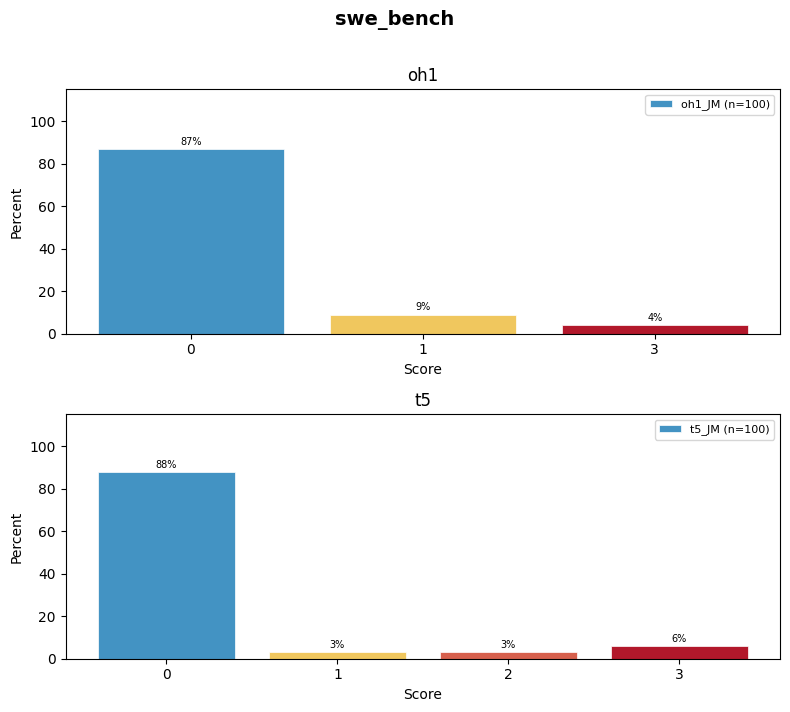

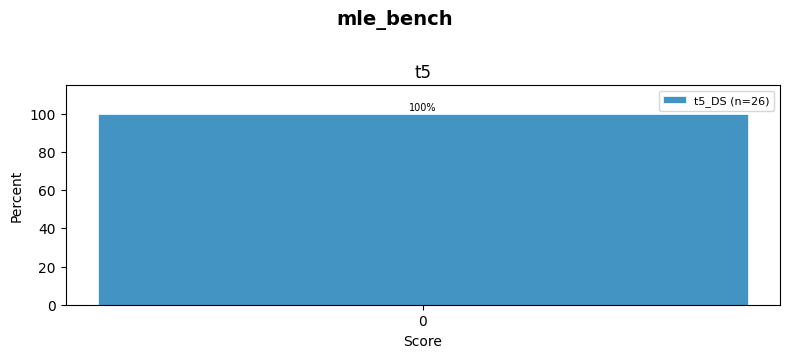

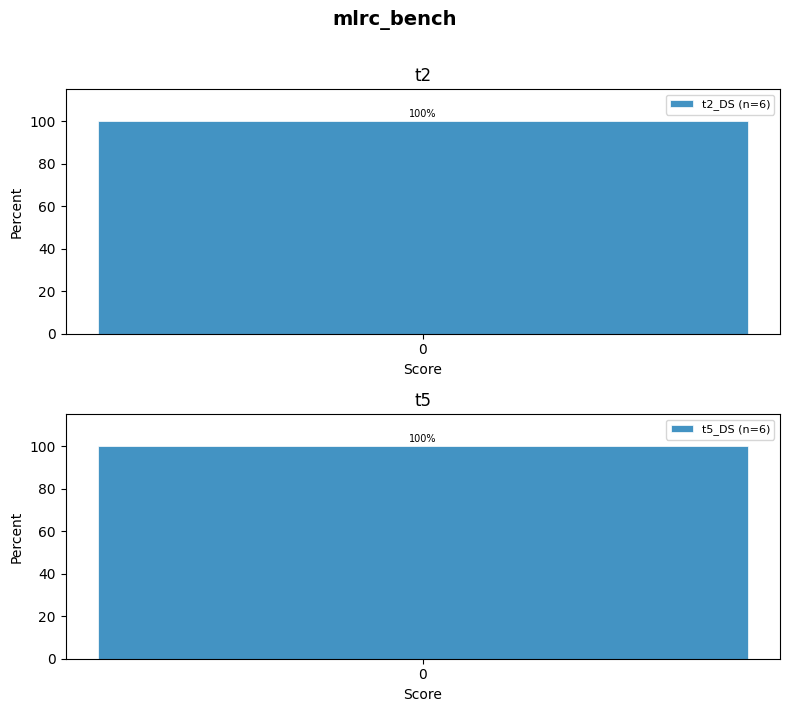

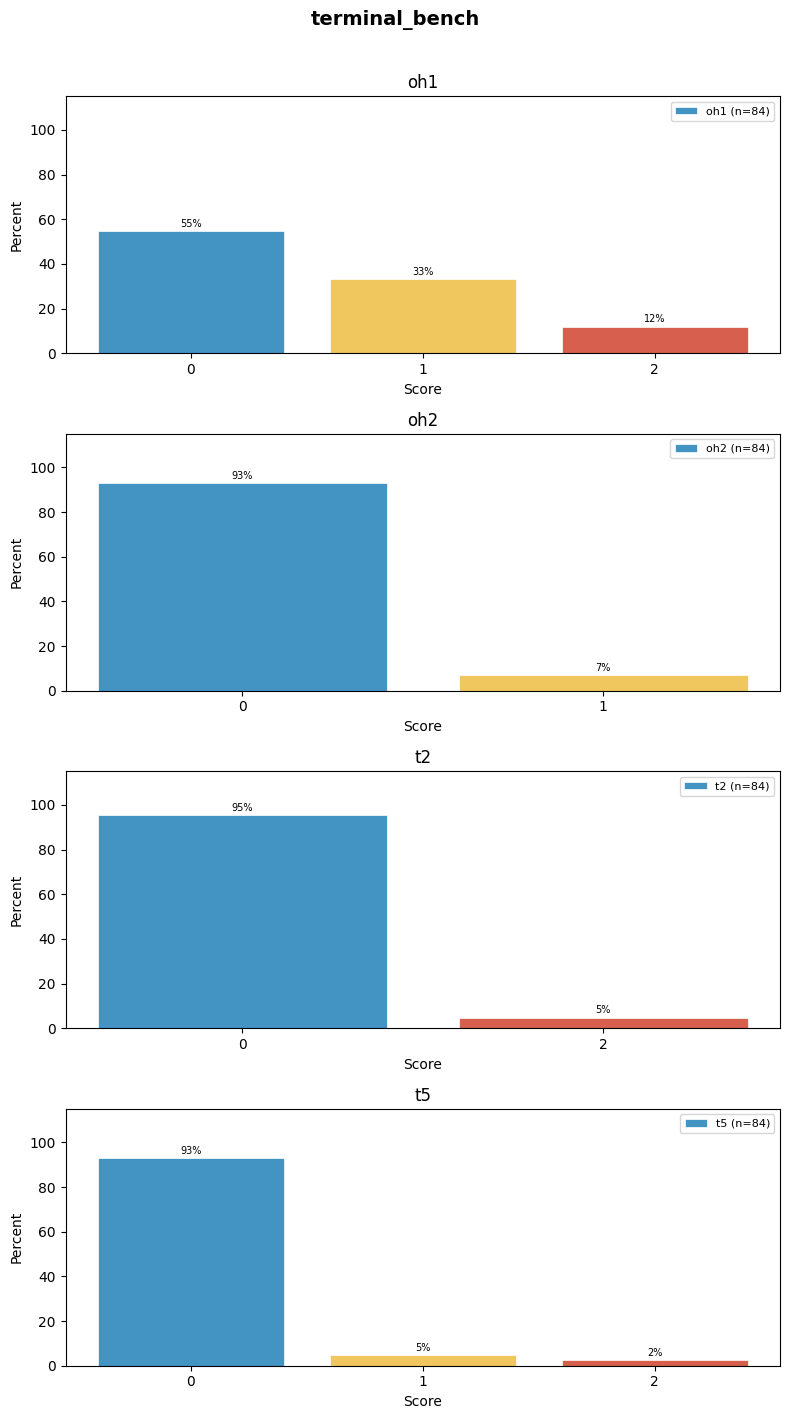

In [10]:
import re

score_colors = {0: "#4393c3", 1: "#f0c75e", 2: "#d6604d", 3: "#b2182b"}

# Group validation columns by label prefix per benchmark
bench_groups: dict[str, list[tuple[str, list[str]]]] = {}  # bench -> [(label, [cols])]

for name, val in all_validations.items():
    cols = [c for c in val.columns if c != "transcript_id"]
    groups: dict[str, list[str]] = {}
    for col in cols:
        m = re.match(r"^([a-zA-Z]+\d*)_", col)
        prefix = m.group(1) if m else col
        groups.setdefault(prefix, []).append(col)
    bench_groups[name] = [(prefix, sorted(gcols)) for prefix, gcols in groups.items()]

for bench, groups in bench_groups.items():
    n_plots = len(groups)
    fig, axes = plt.subplots(n_plots, 1, figsize=(8, 3.5 * n_plots), squeeze=False)
    fig.suptitle(bench, fontsize=14, fontweight="bold", y=1.01)

    for ax, (label, cols) in zip(axes[:, 0], groups):
        all_scores = set()
        for col in cols:
            all_scores.update(all_validations[bench][col].dropna().astype(int).unique())
        score_vals = sorted(all_scores)

        grader_pcts = {}
        grader_ns = {}
        for col in cols:
            vals = all_validations[bench][col].dropna().astype(int)
            counts = vals.value_counts().reindex(score_vals, fill_value=0)
            grader_pcts[col] = counts / counts.sum() * 100
            grader_ns[col] = len(vals)

        pct_df = pd.DataFrame(grader_pcts, index=score_vals)

        n_graders = len(cols)
        n_scores = len(score_vals)
        bar_width = 0.8 / n_graders
        x = range(n_scores)

        for gi, col in enumerate(cols):
            offsets = [xi + gi * bar_width for xi in x]
            bars = ax.bar(
                offsets, pct_df[col], width=bar_width,
                color=[score_colors.get(s, "#999999") for s in score_vals],
                edgecolor="white", linewidth=0.5,
                label=f"{col} (n={grader_ns[col]})",
                alpha=1.0 if gi == 0 else 0.6,
            )
            for bar, s in zip(bars, score_vals):
                p = pct_df.loc[s, col]
                if p > 0:
                    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                            f"{p:.0f}%", ha="center", va="bottom", fontsize=7)

        ax.set_xticks([xi + bar_width * (n_graders - 1) / 2 for xi in x])
        ax.set_xticklabels(score_vals)
        ax.set_xlabel("Score")
        ax.set_ylabel("Percent")
        ax.set_ylim(0, 115)
        ax.set_title(label)
        ax.legend(fontsize=8)

    fig.tight_layout()
    plt.show()


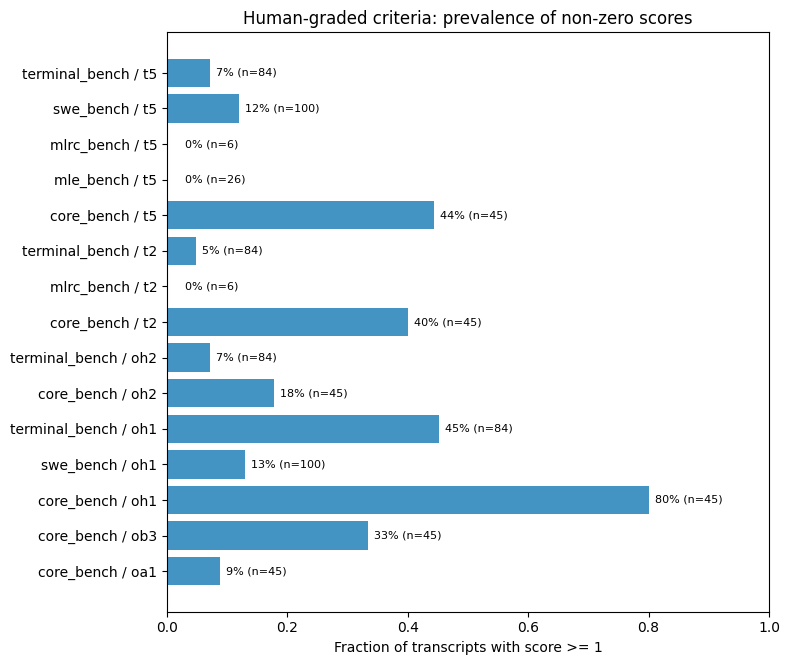

In [12]:
# Fraction of transcripts scoring >= 1, one bar per (benchmark, criterion)
records = []
for bench, val in all_validations.items():
    for col in val.columns:
        if col == "transcript_id":
            continue
        vals = val[col].dropna()
        if vals.empty:
            continue
        m = re.match(r"^([a-zA-Z]+\d*)", col)
        criterion = m.group(1) if m else col
        frac = (vals.astype(float) >= 1).mean()
        records.append({
            "benchmark": bench,
            "criterion": criterion,
            "column": col,
            "frac_gte1": frac,
            "n": len(vals),
        })

agg_df = (
    pd.DataFrame(records)
    .groupby(["benchmark", "criterion"])
    .agg(frac_gte1=("frac_gte1", "mean"), n=("n", "first"))
    .reset_index()
)
agg_df["label"] = agg_df["benchmark"] + " / " + agg_df["criterion"]
agg_df = agg_df.sort_values(["criterion", "benchmark"])

fig, ax = plt.subplots(figsize=(8, max(3, 0.45 * len(agg_df))))
bars = ax.barh(range(len(agg_df)), agg_df["frac_gte1"], color="#4393c3")
ax.set_yticks(range(len(agg_df)))
ax.set_yticklabels(agg_df["label"])
ax.set_xlabel("Fraction of transcripts with score >= 1")
ax.set_xlim(0, 1)
ax.set_title("Human-graded criteria: prevalence of non-zero scores")

for i, (_, row) in enumerate(agg_df.iterrows()):
    ax.text(
        max(row["frac_gte1"] + 0.01, 0.03), i,
        f"{row['frac_gte1']:.0%} (n={int(row['n'])})",
        va="center", fontsize=8,
    )

fig.tight_layout()
plt.show()


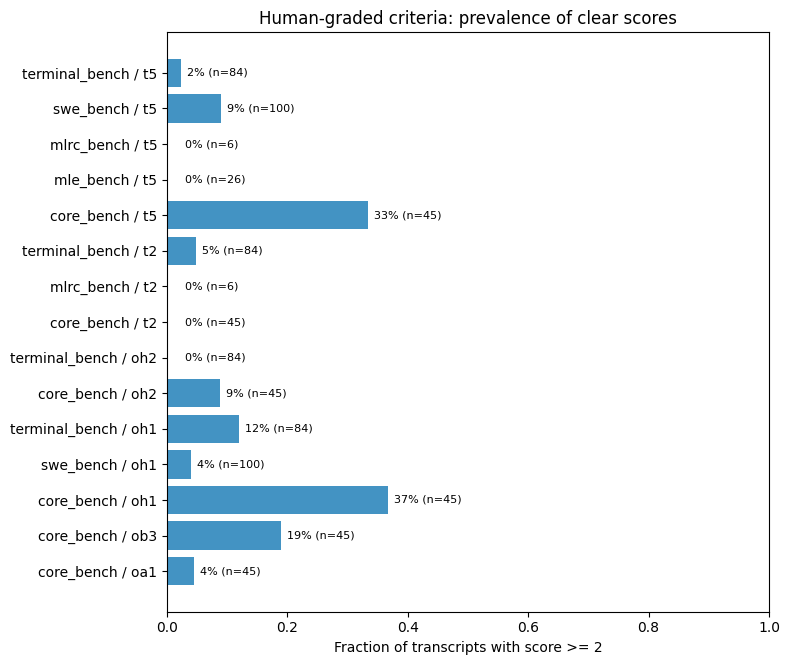

In [15]:
# Fraction of transcripts scoring >= 1, one bar per (benchmark, criterion)
records = []
for bench, val in all_validations.items():
    for col in val.columns:
        if col == "transcript_id":
            continue
        vals = val[col].dropna()
        if vals.empty:
            continue
        m = re.match(r"^([a-zA-Z]+\d*)", col)
        criterion = m.group(1) if m else col
        frac = (vals.astype(float) >= 2).mean()
        records.append({
            "benchmark": bench,
            "criterion": criterion,
            "column": col,
            "frac_gte1": frac,
            "n": len(vals),
        })

agg_df = (
    pd.DataFrame(records)
    .groupby(["benchmark", "criterion"])
    .agg(frac_gte1=("frac_gte1", "mean"), n=("n", "first"))
    .reset_index()
)
agg_df["label"] = agg_df["benchmark"] + " / " + agg_df["criterion"]
agg_df = agg_df.sort_values(["criterion", "benchmark"])

fig, ax = plt.subplots(figsize=(8, max(3, 0.45 * len(agg_df))))
bars = ax.barh(range(len(agg_df)), agg_df["frac_gte1"], color="#4393c3")
ax.set_yticks(range(len(agg_df)))
ax.set_yticklabels(agg_df["label"])
ax.set_xlabel("Fraction of transcripts with score >= 2")
ax.set_xlim(0, 1)
ax.set_title("Human-graded criteria: prevalence of clear scores")

for i, (_, row) in enumerate(agg_df.iterrows()):
    ax.text(
        max(row["frac_gte1"] + 0.01, 0.03), i,
        f"{row['frac_gte1']:.0%} (n={int(row['n'])})",
        va="center", fontsize=8,
    )

fig.tight_layout()
plt.show()


In [17]:
# Summary table: count of transcripts with score >= 1 and >= 2 per criterion
records = []
for bench, val in all_validations.items():
    for col in val.columns:
        if col == "transcript_id":
            continue
        vals = val[col].dropna()
        if vals.empty:
            continue
        m = re.match(r"^([a-zA-Z]+\d*)", col)
        criterion = m.group(1) if m else col
        records.append({
            "criterion": criterion,
            "benchmark": bench,
            "column": col,
            "n_total": len(vals),
            "n_gte1": int((vals.astype(float) >= 1).sum()),
            "n_gte2": int((vals.astype(float) >= 2).sum()),
        })

detail_df = pd.DataFrame(records)

summary_table = (
    detail_df
    .groupby(["criterion", "benchmark"])
    .agg(n_total=("n_total", "first"), n_gte1=("n_gte1", "max"), n_gte2=("n_gte2", "max"))
    .reset_index()
    .groupby("criterion")
    .agg(n_total=("n_total", "sum"), n_gte1=("n_gte1", "sum"), n_gte2=("n_gte2", "sum"))
)
summary_table["pct_gte1"] = summary_table["n_gte1"] / summary_table["n_total"]
summary_table["pct_gte2"] = summary_table["n_gte2"] / summary_table["n_total"]
summary_table = summary_table[["n_total", "n_gte1", "pct_gte1", "n_gte2", "pct_gte2"]].sort_index()

display(
    summary_table.style
    .format({
        "pct_gte1": "{:.1%}", "pct_gte2": "{:.1%}",
        "n_total": "{:d}", "n_gte1": "{:d}", "n_gte2": "{:d}",
    })
    .set_caption("Transcripts with human grade >= 1 / >= 2, aggregated across benchmarks")
)


,n_total,n_gte1,pct_gte1,n_gte2,pct_gte2
criterion,,,,,
oa1,45,4,8.9%,2,4.4%
ob3,45,15,33.3%,10,22.2%
oh1,229,96,41.9%,43,18.8%
oh2,129,20,15.5%,8,6.2%
t2,135,22,16.3%,4,3.0%
t5,261,38,14.6%,26,10.0%


## 6. Scanner vs human grading (where both exist)

In [21]:
from sklearn.metrics import cohen_kappa_score
from scipy.stats import spearmanr

# Map: (benchmark, human_col) -> scanner_key
# Extend this mapping as new scanner/grading pairs become available.
GRADING_PAIRS = {
    "swe_bench": [("oh1_JM", "answer_format"), ("t5_JM", "ground_truth_access")],
    "core_bench": [("oh1_JM", "answer_format"), ("oh1_AH", "answer_format")],
}

# Build per-benchmark summaries with scans + validations (renames applied)
bench_summaries: dict[str, pd.DataFrame] = {}

rows = []
for bench, pairs in GRADING_PAIRS.items():
    cfg = BENCHMARKS[bench]
    scan_dir = cfg.get("scan_results_dir")
    val_dir = cfg.get("validation_dir")
    if scan_dir is None or val_dir is None:
        continue
    if bench not in all_validations:
        continue

    try:
        scans = load_scan_results(scan_dir)
    except FileNotFoundError:
        continue

    summary = build_summary(
        all_logs[bench], scans=scans,
        validation_dir=val_dir,
        validation_prefix=cfg.get("validation_prefix", ""),
    )
    renames = cfg.get("validation_renames")
    if renames:
        summary = summary.rename(columns=renames)
    bench_summaries[bench] = summary

    for human_col, scanner_col in pairs:
        if human_col not in summary.columns or scanner_col not in summary.columns:
            continue
        mask = summary[human_col].notna() & summary[scanner_col].notna()
        if mask.sum() < 5:
            continue
        h = summary.loc[mask, human_col]
        s = summary.loc[mask, scanner_col]
        kappa = cohen_kappa_score(h, s)
        agreement = (h == s).mean()
        rho, pval = spearmanr(h.astype(float), s.astype(float))
        rows.append({
            "benchmark": bench,
            "human_col": human_col,
            "scanner_col": scanner_col,
            "n": int(mask.sum()),
            "agreement": agreement,
            "cohen_kappa": kappa,
            "spearman_rho": rho,
            "spearman_p": pval,
        })

# Inter-rater reliability between human graders
HUMAN_PAIRS = {
    "core_bench": [("oh1_JM", "oh1_AH"), ("ob3_JM", "ob3_AH"), ("oh2_JM", "oh2_AH")],
}

for bench, pairs in HUMAN_PAIRS.items():
    if bench not in all_validations:
        continue
    val = all_validations[bench]
    for col_a, col_b in pairs:
        if col_a not in val.columns or col_b not in val.columns:
            continue
        mask = val[col_a].notna() & val[col_b].notna()
        if mask.sum() < 5:
            continue
        a = val.loc[mask, col_a]
        b = val.loc[mask, col_b]
        kappa = cohen_kappa_score(a, b)
        agreement = (a == b).mean()
        rho, pval = spearmanr(a.astype(float), b.astype(float))
        rows.append({
            "benchmark": bench,
            "human_col": col_a,
            "scanner_col": col_b,
            "n": int(mask.sum()),
            "agreement": agreement,
            "cohen_kappa": kappa,
            "spearman_rho": rho,
            "spearman_p": pval,
        })

if rows:
    irr_df = pd.DataFrame(rows)
    display(irr_df.style.format({
        "agreement": "{:.1%}",
        "cohen_kappa": "{:.3f}",
        "spearman_rho": "{:.3f}",
        "spearman_p": "{:.4f}",
    }))
else:
    print("No scanner/human grading pairs available for comparison.")


,benchmark,human_col,scanner_col,n,agreement,cohen_kappa,spearman_rho,spearman_p
0,swe_bench,oh1_JM,answer_format,100,51.0%,0.025,0.047,0.6409
1,swe_bench,t5_JM,ground_truth_access,100,66.0%,0.216,0.436,0.0000
2,core_bench,oh1_JM,answer_format,45,77.8%,0.601,0.656,0.0000
3,core_bench,oh1_AH,answer_format,45,0.0%,-0.207,0.720,0.0000
4,core_bench,oh1_JM,oh1_AH,45,8.9%,-0.191,0.787,0.0000
5,core_bench,ob3_JM,ob3_AH,45,68.9%,0.399,0.613,0.0000
6,core_bench,oh2_JM,oh2_AH,45,68.9%,0.074,0.377,0.0108


## 7. Confusion matrices for scanner vs human

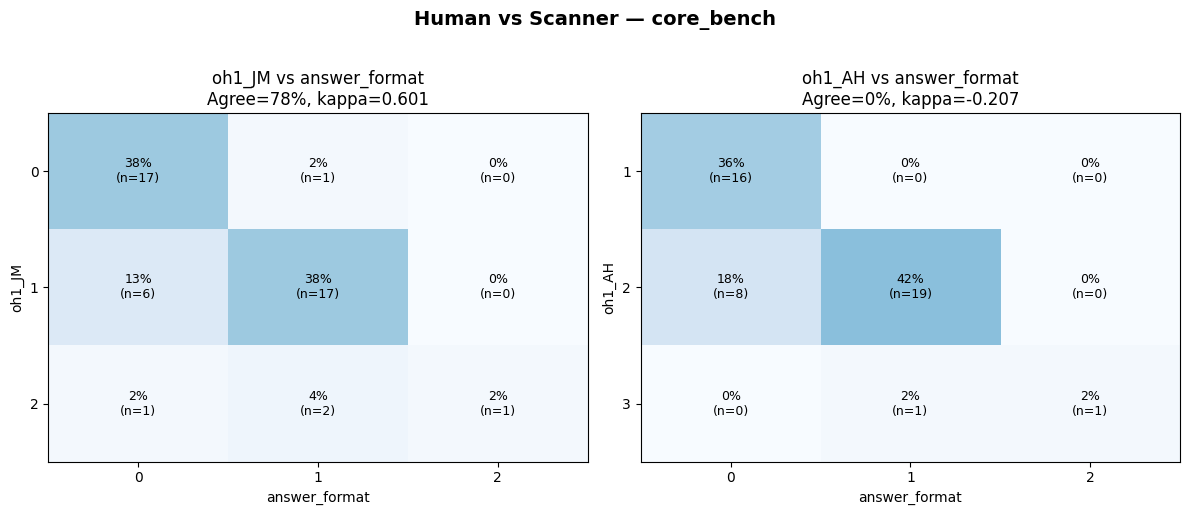

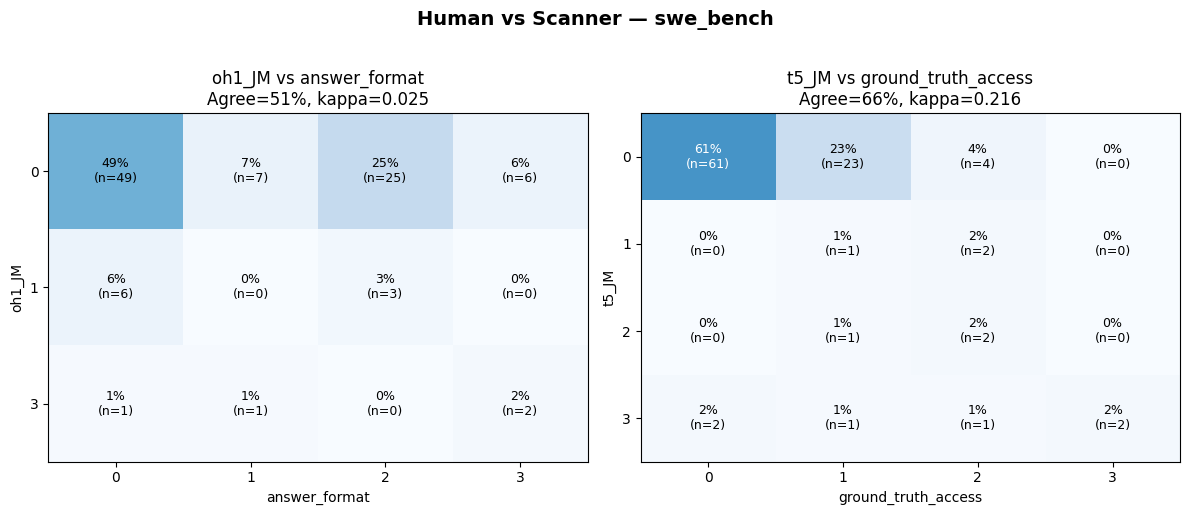

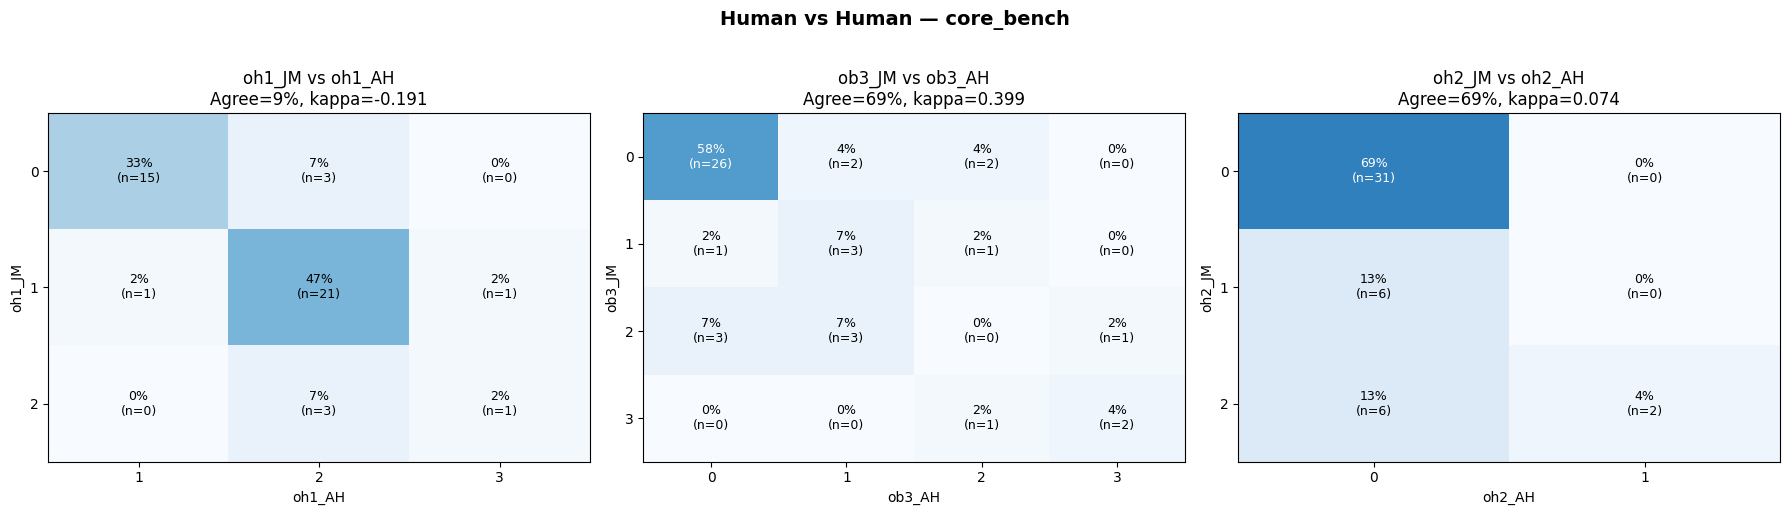

In [19]:
if rows:
    # Split rows by type and benchmark
    scanner_rows = [r for r in rows if r["scanner_col"] not in 
                    [c for val in all_validations.values() for c in val.columns]]
    human_rows = [r for r in rows if r not in scanner_rows]

    for title, subset in [("Human vs Scanner", scanner_rows), ("Human vs Human", human_rows)]:
        if not subset:
            continue

        # Group by benchmark
        benches = sorted(set(r["benchmark"] for r in subset))
        for bench in benches:
            bench_rows = [r for r in subset if r["benchmark"] == bench]
            n_plots = len(bench_rows)
            fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5), squeeze=False)

            for ax, r in zip(axes[0], bench_rows):
                human_col, other_col = r["human_col"], r["scanner_col"]

                # Use bench_summaries if available (has scanner cols), else validations
                if bench in bench_summaries and other_col in bench_summaries[bench].columns:
                    src = bench_summaries[bench]
                else:
                    src = all_validations[bench]

                mask = src[human_col].notna() & src[other_col].notna()
                sub = src[mask]

                ct = pd.crosstab(
                    sub[human_col].astype(int).rename(human_col),
                    sub[other_col].astype(int).rename(other_col),
                )
                ct_pct = ct / ct.values.sum() * 100

                ax.imshow(ct_pct.values, cmap="Blues", vmin=0, vmax=100, aspect="auto")
                ax.set_xticks(range(len(ct_pct.columns)))
                ax.set_xticklabels(ct_pct.columns)
                ax.set_yticks(range(len(ct_pct.index)))
                ax.set_yticklabels(ct_pct.index)
                ax.set_xlabel(other_col)
                ax.set_ylabel(human_col)
                ax.set_title(
                    f"{human_col} vs {other_col}\n"
                    f"Agree={r['agreement']:.0%}, kappa={r['cohen_kappa']:.3f}"
                )

                for i in range(len(ct_pct.index)):
                    for j in range(len(ct_pct.columns)):
                        pct = ct_pct.values[i, j]
                        count = ct.values[i, j]
                        color = "white" if pct > 50 else "black"
                        ax.text(j, i, f"{pct:.0f}%\n(n={count})", ha="center", va="center",
                                color=color, fontsize=9)

            fig.suptitle(f"{title} — {bench}", y=1.02, fontsize=14, fontweight="bold")
            fig.tight_layout()
            plt.show()
else:
    print("No confusion matrices to show.")
